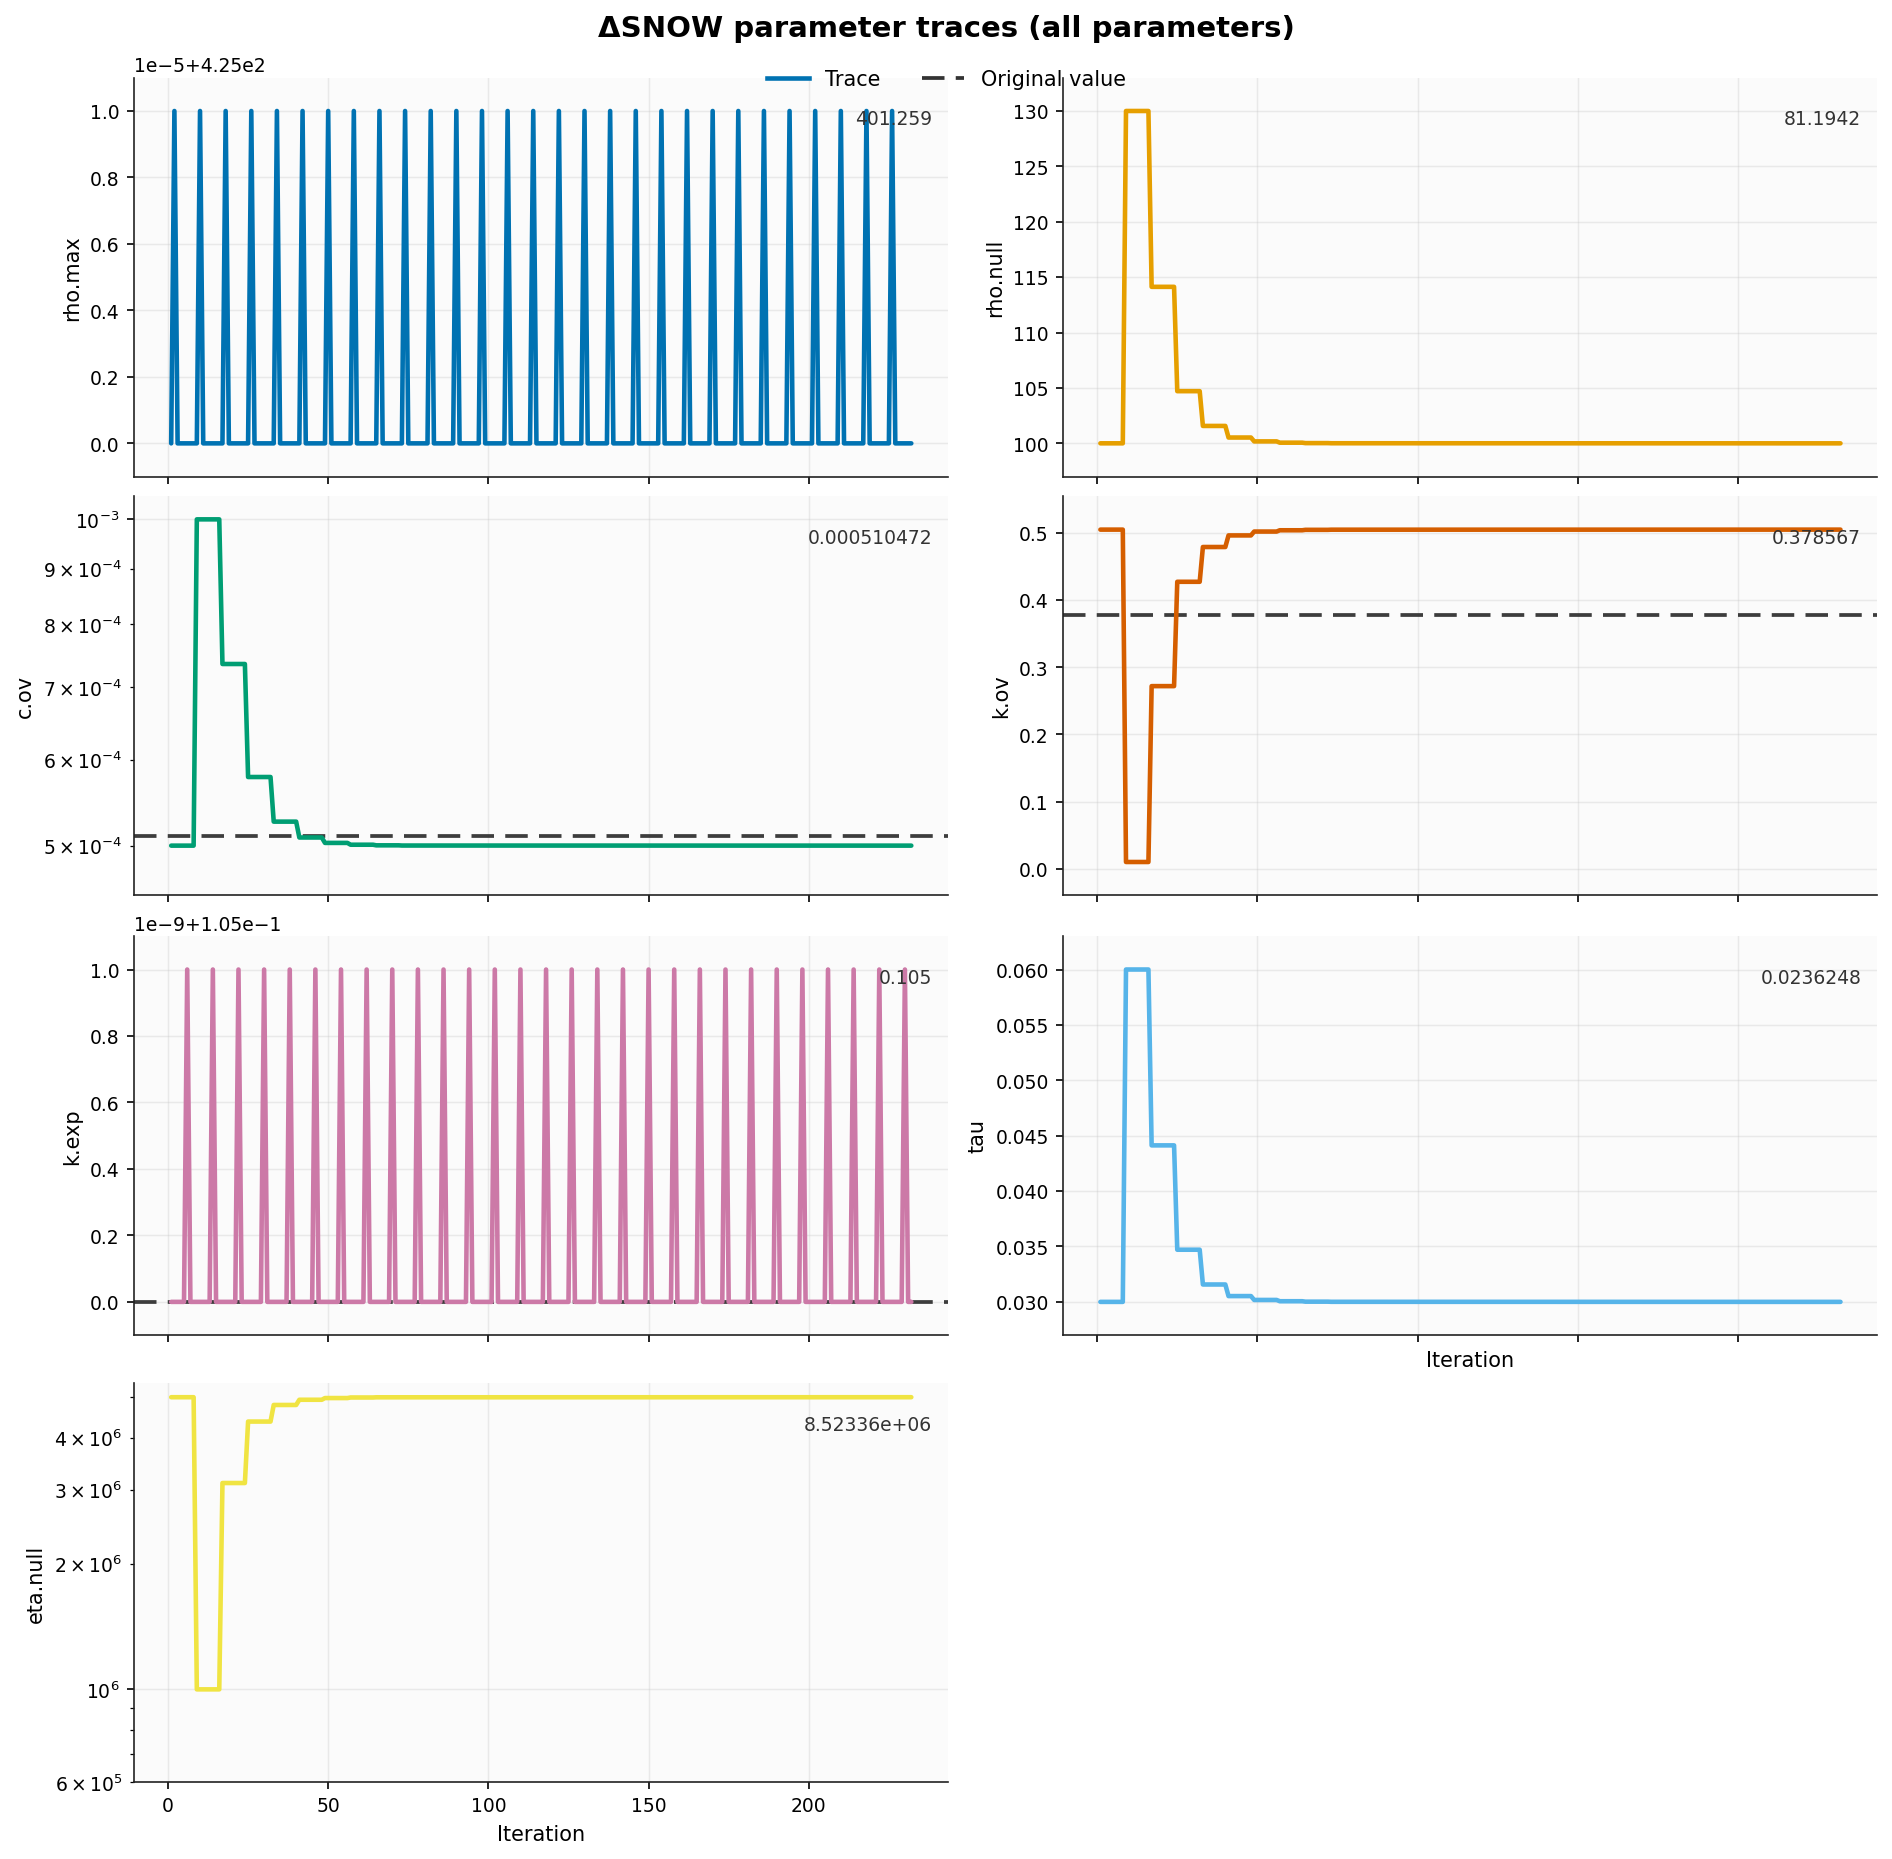

In [10]:
df = pd.read_csv("/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_py/L-BFGS-B/finished_runs/exp_rsme_penalty/calibration_log.csv")

plot_param_traces_nice(
    df,
    iteration_col="iteration",
    param_cols=param_cols,
    orig_params=dsnow_params,
    ncols=2,
    title="ΔSNOW parameter traces (all parameters)",
    log_params=("eta.null", "c.ov"),
)

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_param_traces_nice(
    df,
    iteration_col="iteration",
    param_cols=None,
    orig_params=None,
    ncols=2,
    title="Parameter traces",
    log_params=("eta.null", "c.ov"),
):
    if orig_params is None:
        orig_params = {}

    if iteration_col in df.columns:
        x = df[iteration_col].to_numpy()
        xlab = "Iteration"
    else:
        x = np.arange(len(df))
        xlab = "Index"

    # Default: plot all numeric columns except iteration
    if param_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        param_cols = [c for c in numeric_cols if c != iteration_col]

    n = len(param_cols)
    nrows = math.ceil(n / ncols)

    palette = [
        "#0072B2", "#E69F00", "#009E73", "#D55E00",
        "#CC79A7", "#56B4E9", "#F0E442", "#000000",
    ]

    plt.rcParams.update({
        "figure.dpi": 150,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.facecolor": "#FBFBFB",
        "figure.facecolor": "white",
        "axes.edgecolor": "#222222",
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.color": "#C9C9C9",
        "grid.linestyle": "-",
        "grid.linewidth": 0.7,
    })

    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12.5, 3.0 * nrows),
        sharex=True,
        constrained_layout=True
    )
    axs = np.array(axs).reshape(-1)

    trace_handle = Line2D([0], [0], color=palette[0], lw=2.2, label="Trace")
    orig_handle  = Line2D([0], [0], color="#333333", lw=1.8, ls=(0, (6, 3)), label="Original value")

    for i, p in enumerate(param_cols):
        ax = axs[i]
        y = df[p].to_numpy(dtype=float)

        color = palette[i % len(palette)]
        ax.plot(x, y, color=color, lw=2.2, solid_capstyle="round", zorder=3)

        if p in orig_params:
            ref = float(orig_params[p])
            ax.axhline(ref, color="#333333", lw=1.8, ls=(0, (6, 3)), alpha=0.95, zorder=2)
            ax.text(
                0.98, 0.92, f"{ref:.6g}",
                transform=ax.transAxes,
                ha="right", va="top",
                fontsize=9,
                color="#333333"
            )

        ax.grid(True, alpha=0.35, zorder=1)
        ax.set_ylabel(p)

        if p in log_params:
            ymin = np.nanmin(y)
            ref_ok = (p not in orig_params) or (orig_params[p] > 0)
            if ymin > 0 and ref_ok:
                ax.set_yscale("log")

        q1, q99 = np.nanpercentile(y, [1, 99])
        if np.isfinite(q1) and np.isfinite(q99) and q1 != q99:
            pad = 0.10 * (q99 - q1)
            ax.set_ylim(q1 - pad, q99 + pad)

    for j in range(n, len(axs)):
        fig.delaxes(axs[j])

    # x-label on last row
    start_last_row = max(0, n - ncols)
    for ax in axs[start_last_row:n]:
        ax.set_xlabel(xlab)

    fig.suptitle(title, y=1.02, fontsize=14, fontweight="semibold")
    fig.legend(
        handles=[trace_handle, orig_handle],
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.00)
    )
    plt.show()

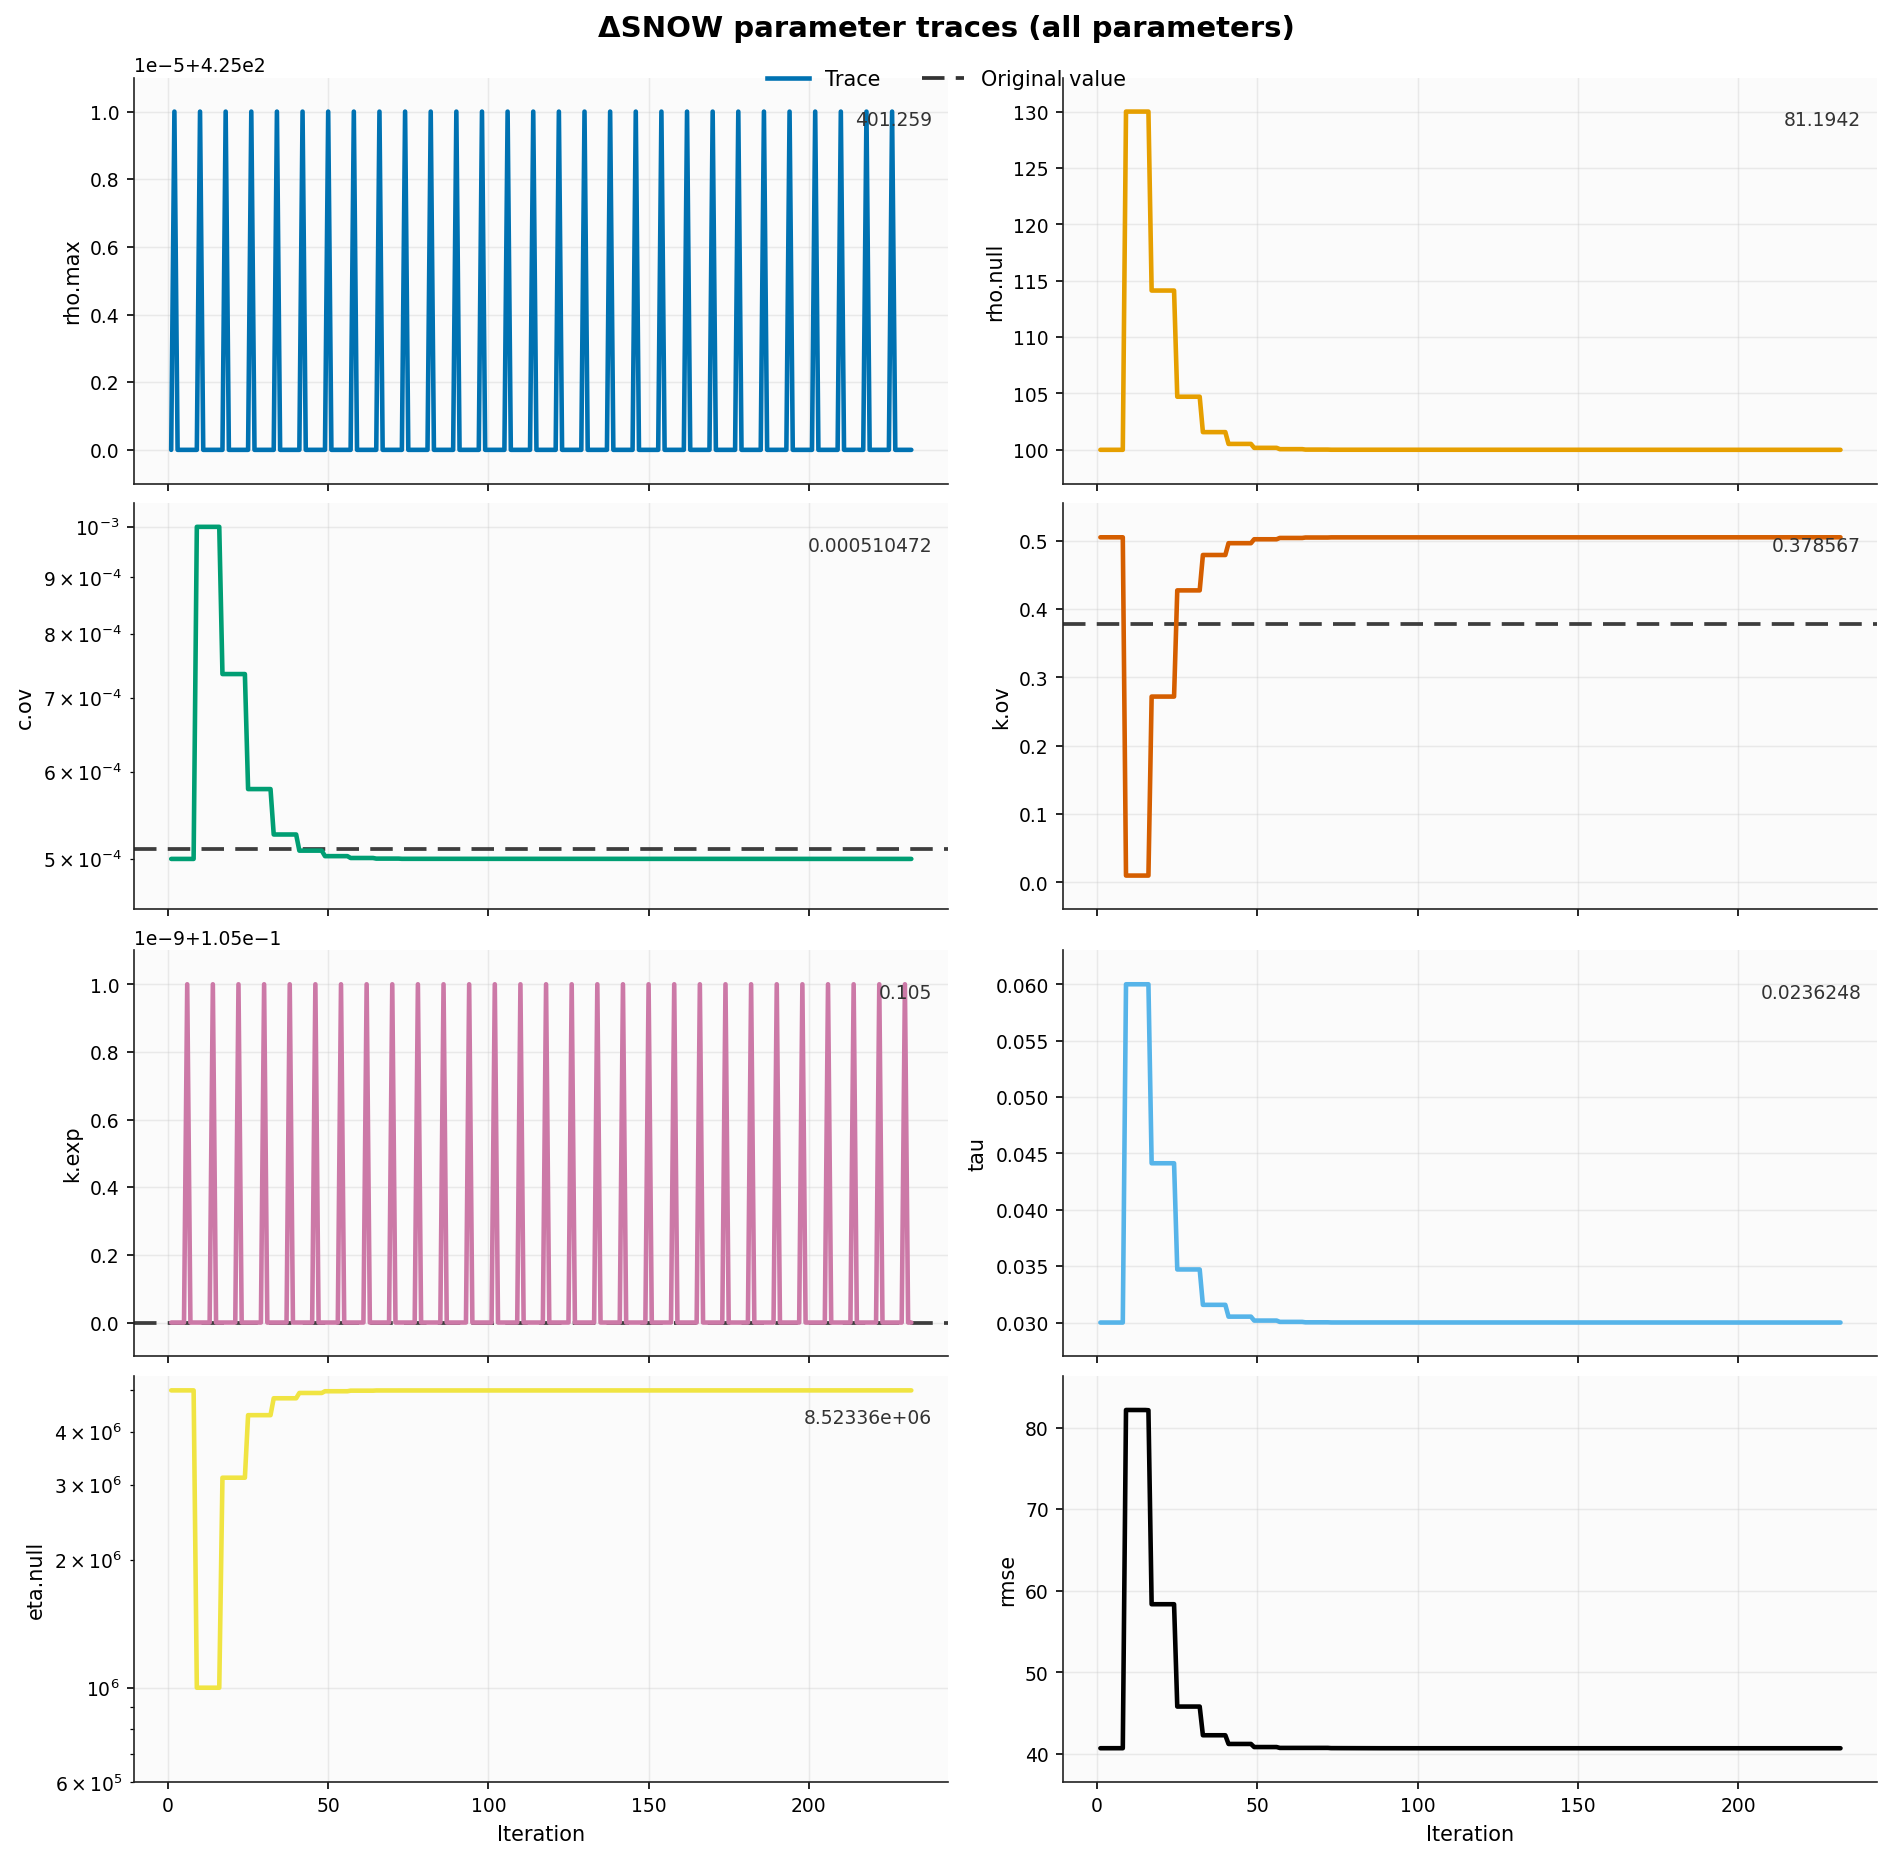

In [11]:
# Your "original" parameter values (update k.exp if you have it)
dsnow_params = {
    "rho.max": 401.2588,
    "rho.null": 81.19417,
    "c.ov": 0.0005104722,
    "k.ov": 0.37856737,
    "k.exp": 0.10499999999999998,   # <-- add if you want a reference line
    "tau": 0.02362476,
    "eta.null": 8523356,
}

param_cols = ["rho.max", "rho.null", "c.ov", "k.ov", "k.exp", "tau", "eta.null", "rmse"]

plot_param_traces_nice(
    df,
    iteration_col="iteration",
    param_cols=param_cols,
    orig_params=dsnow_params,
    ncols=2,
    title="ΔSNOW parameter traces (all parameters)",
    log_params=("eta.null", "c.ov"),
)